# 🇱🇰 Sri Lankan Traffic Sign Recognition

**Hybrid ConvNeXt + Transformer Model** trained on synthetic Sri Lankan traffic signs.

| Component | Setting |
|---|---|
| Architecture | ConvNeXt-Tiny + 2-layer Transformer + SE-Block |
| Classes | 122 Sri Lankan traffic signs |
| Loss | Focal Loss + Label Smoothing |
| Scheduler | Linear Warmup → Cosine Annealing |
| Augmentation | Motion blur, rain, fog, occlusion, perspective + Mixup |
| Regularization | Dropout 0.3, Weight Decay 5e-4, Gradient Clipping |

---
## 1. Setup & Configuration

In [1]:
import os
import sys
from pathlib import Path
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.size'] = 11

# Add src to path
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))

from src.data import get_dataloaders
from src.models.hybrid_model import create_model
from src.training import Trainer, CombinedLoss
from src.training.losses import create_loss_function

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔹 Project Root: {project_root}")
print(f"🔹 Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"🔹 PyTorch: {torch.__version__}")

🔹 Project Root: D:\APIIT\FYP\Traffic-Sign-Recognition
🔹 Device: NVIDIA GeForce RTX 3050 Laptop GPU
🔹 PyTorch: 2.5.1+cu121


In [2]:
# Load configuration
config_path = project_root / "config_sri_lanka.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Resolve paths to be absolute relative to project root
for key in ['models_dir', 'outputs_dir', 'logs_dir']:
    if key in config['paths']:
        config['paths'][key] = str(project_root / config['paths'][key])

print("✅ Configuration Loaded")
print(f"   Classes:     {config['dataset']['num_classes']}")
print(f"   Backbone:    {config['model']['backbone']}")
print(f"   Epochs:      {config['training']['epochs']}")
print(f"   Batch Size:  {config['training']['batch_size']}")
print(f"   LR:          {config['training']['learning_rate']}")
print(f"   Weight Decay:{config['training']['weight_decay']}")
print(f"   Dropout:     {config['model']['dropout']}")
print(f"   AMP:         {config['training']['use_amp']}")

✅ Configuration Loaded
   Classes:     122
   Backbone:    convnext_small
   Epochs:      100
   Batch Size:  32
   LR:          0.0001
   Weight Decay:0.0005
   Dropout:     0.3
   AMP:         True


---
## 2. Generate Annotations
Create `Train.csv` if it doesn't exist yet.

In [3]:
data_dir = project_root / "sri_lankan_traffc_signs/synthetic"
csv_script = project_root / "create_csv_annotations.py"

if not (data_dir / "Train.csv").exists():
    print("🔸 Generating CSV annotations...")
    !python {csv_script} --data-dir {data_dir}
else:
    print("✅ Train.csv already exists.")

✅ Train.csv already exists.


---
## 3. Load Data & Preview

In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    data_dir=config['dataset']['path'],
    batch_size=config['training']['batch_size'],
    val_split=config['dataset']['val_split'],
    image_size=config['dataset']['image_size'],
    num_workers=0,  # Set to 0 for Windows notebooks
    use_weighted_sampler=True,
    seed=config['seed']
)

print(f"📊 Dataset Summary")
print(f"   Train samples: {len(train_loader.dataset):,}")
print(f"   Val samples:   {len(val_loader.dataset):,}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Classes:       {config['dataset']['num_classes']}")

📊 Dataset Summary
   Train samples: 6,050
   Val samples:   1,068
   Train batches: 189
   Val batches:   34
   Classes:       122


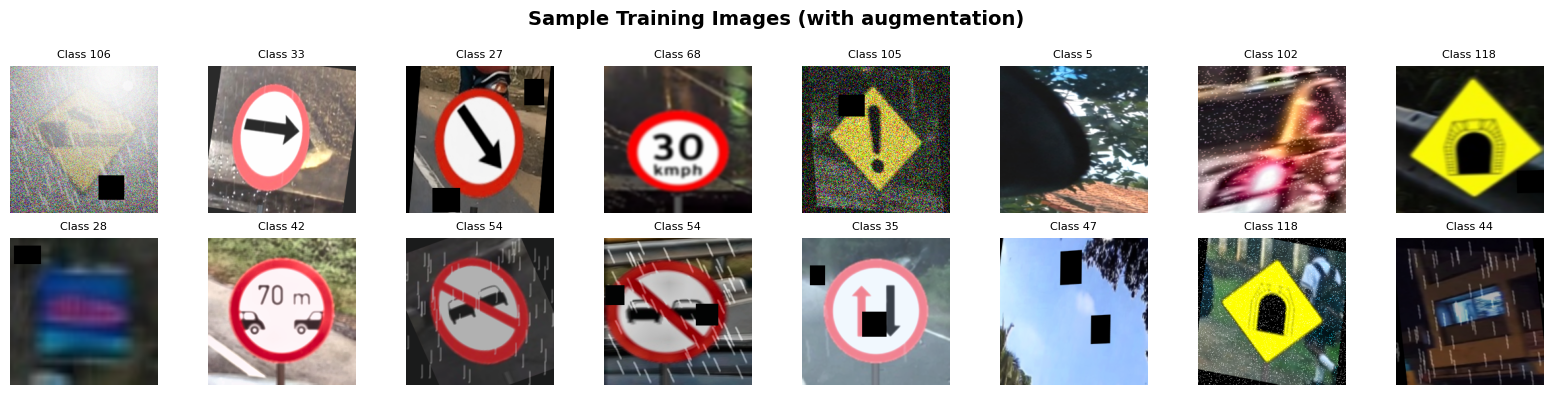

In [5]:
# Preview a batch of training images
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Sample Training Images (with augmentation)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(images):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = img * IMAGENET_STD + IMAGENET_MEAN  # Denormalize
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(f'Class {labels[i].item()}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 4. Initialize Model

In [6]:
model = create_model(config)
model = model.to(device)

# Class weights for loss function
class_weights = train_loader.dataset.get_class_weights().to(device)
criterion = create_loss_function(config, class_weights)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🧠 Model Summary")
print(f"   Backbone:          {config['model']['backbone']}")
print(f"   Total params:      {total_params:,}")
print(f"   Trainable params:  {trainable_params:,}")
print(f"   Loss:              Focal (γ={config['training']['focal_loss_gamma']}) + Label Smoothing ({config['training']['label_smoothing']})")
print(f"   Class weights:     min={class_weights.min():.2f}, max={class_weights.max():.2f}")

🧠 Model Summary
   Backbone:          convnext_small
   Total params:      53,589,338
   Trainable params:  53,589,338
   Loss:              Focal (γ=2.0) + Label Smoothing (0.1)
   Class weights:     min=0.45, max=49.59


In [7]:
# Create trainer
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    config=config,
    device=device
)

print("✅ Trainer initialized")
print(f"   Scheduler:      Linear Warmup ({config['training']['warmup_epochs']} epochs) → Cosine Annealing")
print(f"   Early Stopping: Patience=15, monitoring val F1")
print(f"   Gradient Clip:  max_norm=1.0")
print(f"   Mixup:          Enabled (50% probability, β=0.2)")

SAM disabled: incompatible with AMP mixed precision. SWA remains active.


✅ Trainer initialized
   Scheduler:      Linear Warmup (5 epochs) → Cosine Annealing
   Early Stopping: Patience=15, monitoring val F1
   Gradient Clip:  max_norm=1.0
   Mixup:          Enabled (50% probability, β=0.2)


D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if self.use_amp else None


---
## 5. 🚀 Training

Training will run for up to 100 epochs but will early-stop when validation F1 stops improving.

In [8]:
print("🚀 Starting Training...")
print(f"   Max epochs: {config['training']['epochs']}")
print(f"   Device: {device}")
print("   (Will auto-stop when F1 plateaus)\n")

history = trainer.train()

🚀 Starting Training...
   Max epochs: 100
   Device: cuda
   (Will auto-stop when F1 plateaus)



Epoch 1/100 [Train]:   0%|                                                                     | 0/189 [00:00<?, ?it/s]D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:324: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/100 [Train]:   1%|▏                                   | 1/189 [00:01<05:33,  1.77s/it, loss=4.5671, acc=0.0000]D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:324: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/100 [Train]:   1%|▍                                   | 2/189 [00:03<04:40,  1.50s/it, loss=6.3427, acc=0.0000]D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:324: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/100 [Tra


Epoch 1/100
  Train - Loss: 5.0143, Acc: 0.0063
  Val   - Loss: 4.4367, Acc: 0.0056, F1: 0.0047
  LR: 0.000021 | Best F1: 0.0047 (epoch 1)


Epoch 2/100 [Train]:   0%|                                                                     | 0/189 [00:00<?, ?it/s]D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:324: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 2/100 [Train]:   1%|▏                                   | 1/189 [00:01<06:12,  1.98s/it, loss=4.4927, acc=0.0000]D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:324: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 2/100 [Train]:   1%|▍                                   | 2/189 [00:03<05:35,  1.79s/it, loss=4.5601, acc=0.0156]D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:324: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 2/100 [Tra


Epoch 2/100
  Train - Loss: 4.8565, Acc: 0.0493
  Val   - Loss: 4.0117, Acc: 0.2575, F1: 0.2557
  LR: 0.000041 | Best F1: 0.2557 (epoch 2)


...


Epoch 30/100
  Train - Loss: 1.6787, Acc: 0.4555
  Val   - Loss: 1.7349, Acc: 0.6845, F1: 0.7027
  LR: 0.000015 | Best F1: 0.7293 (epoch 12)


Epoch 31/100 [Train]:   0%|                                                                    | 0/189 [00:00<?, ?it/s]D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:324: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 31/100 [Train]:   1%|▏                                  | 1/189 [00:01<05:01,  1.60s/it, loss=1.2351, acc=0.0000]D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:324: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 31/100 [Train]:   1%|▎                                  | 2/189 [00:03<04:57,  1.59s/it, loss=1.6491, acc=0.3438]D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:324: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 31/100 [Tr


Epoch 31/100
  Train - Loss: 1.7323, Acc: 0.4894
  Val   - Loss: 1.7307, Acc: 0.6854, F1: 0.7061
  LR: 0.000010 | Best F1: 0.7293 (epoch 12)


Epoch 32/100 [Train]:   0%|                                                                    | 0/189 [00:00<?, ?it/s]D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:324: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 32/100 [Train]:   1%|▏                                  | 1/189 [00:01<05:43,  1.83s/it, loss=1.3723, acc=0.0312]D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:324: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 32/100 [Train]:   1%|▎                                  | 2/189 [00:03<05:24,  1.73s/it, loss=2.6764, acc=0.1875]D:\APIIT\FYP\Traffic-Sign-Recognition\src\training\trainer.py:324: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 32/100 [Tr


Epoch 32/100
  Train - Loss: 1.7680, Acc: 0.4403
  Val   - Loss: 1.7362, Acc: 0.6863, F1: 0.7081
  LR: 0.000006 | Best F1: 0.7293 (epoch 12)

Early stopping triggered at epoch 32

Updating SWA model batch normalization...
SWA model saved to D:\APIIT\FYP\Traffic-Sign-Recognition\models_sri_lanka\best_model_swa.pth


---
## 6. 📊 Training Curves

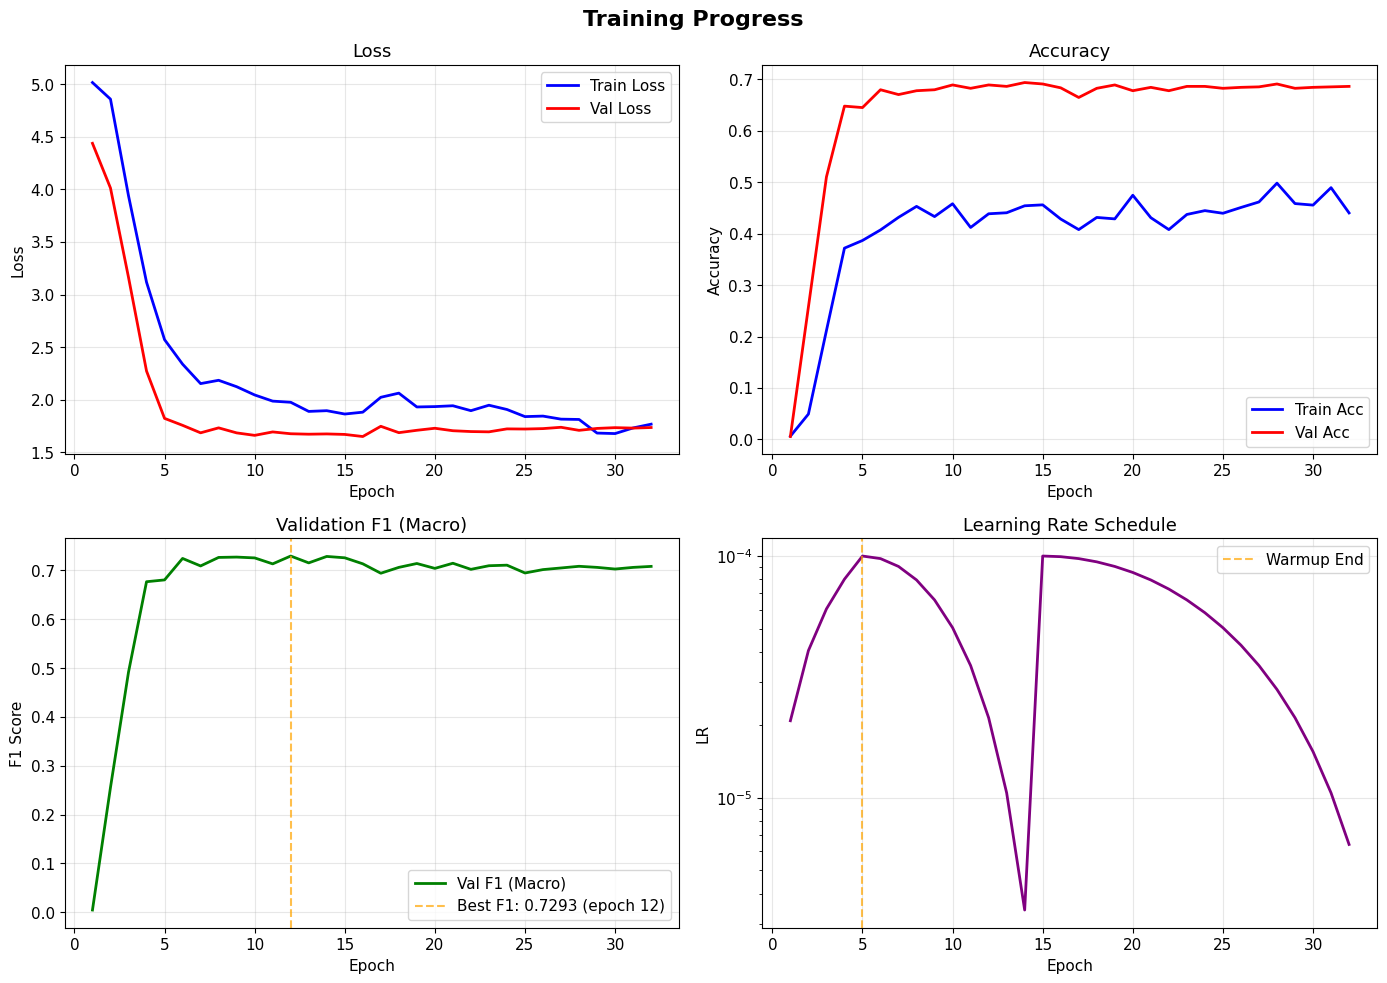


📈 Training Summary
   Epochs trained:    32
   Best Val Accuracy: 0.6938
   Best Val F1:       0.7293 (epoch 12)
   Final Train Loss:  1.7680
   Final Val Loss:    1.7362


In [9]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Progress', fontsize=16, fontweight='bold')

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_title('Loss', fontsize=13)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
axes[0, 1].plot(epochs_range, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
axes[0, 1].set_title('Accuracy', fontsize=13)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
axes[1, 0].plot(epochs_range, history['val_f1'], 'g-', label='Val F1 (Macro)', linewidth=2)
best_f1_epoch = np.argmax(history['val_f1']) + 1
best_f1 = max(history['val_f1'])
axes[1, 0].axvline(x=best_f1_epoch, color='orange', linestyle='--', alpha=0.7, label=f'Best F1: {best_f1:.4f} (epoch {best_f1_epoch})')
axes[1, 0].set_title('Validation F1 (Macro)', fontsize=13)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(epochs_range, history['lr'], 'purple', linewidth=2)
axes[1, 1].set_title('Learning Rate Schedule', fontsize=13)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('LR')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(x=config['training']['warmup_epochs'], color='orange', linestyle='--', alpha=0.7, label='Warmup End')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(str(Path(config['paths']['outputs_dir']) / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📈 Training Summary")
print(f"   Epochs trained:    {len(history['train_loss'])}")
print(f"   Best Val Accuracy: {max(history['val_acc']):.4f}")
print(f"   Best Val F1:       {best_f1:.4f} (epoch {best_f1_epoch})")
print(f"   Final Train Loss:  {history['train_loss'][-1]:.4f}")
print(f"   Final Val Loss:    {history['val_loss'][-1]:.4f}")

---
## 7. 🧪 Test Set Evaluation

In [10]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

# Load best model
best_model_path = Path(config['paths']['models_dir']) / 'best_model_weights.pth'
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print(f"✅ Loaded best model from: {best_model_path.name}")

# Run inference on test set
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Metrics
test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average='macro')
test_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
test_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)

print(f"\n🧪 Test Set Results")
print(f"   {'='*35}")
print(f"   Accuracy:   {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   F1 (Macro): {test_f1:.4f}")
print(f"   Precision:  {test_precision:.4f}")
print(f"   Recall:     {test_recall:.4f}")
print(f"   {'='*35}")

# Save test metrics
import json
test_metrics = {
    'test_accuracy': float(test_acc),
    'test_f1': float(test_f1),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_samples': len(all_labels)
}
with open(Path(config['paths']['outputs_dir']) / 'test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)
print(f"\n   Saved to: {config['paths']['outputs_dir']}/test_metrics.json")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_34776\3155435860.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio

✅ Loaded best model from: best_model_weights.pth

🧪 Test Set Results
   Accuracy:   0.7017 (70.17%)
   F1 (Macro): 0.7161
   Precision:  0.8143
   Recall:     0.6763

   Saved to: D:\APIIT\FYP\Traffic-Sign-Recognition\outputs_sri_lanka/test_metrics.json


---
## 8. 📊 Confusion Matrix

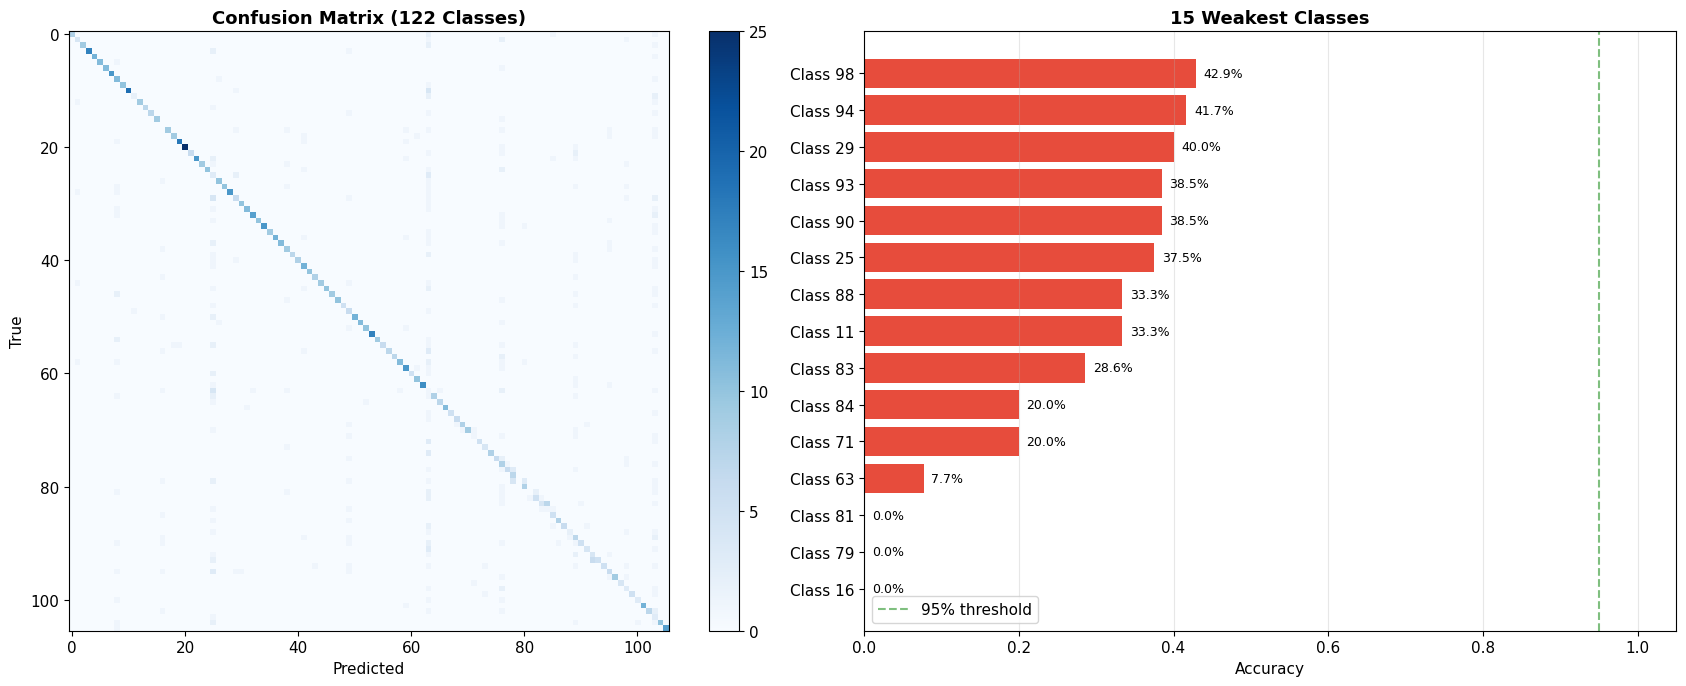


📊 Per-Class Breakdown: 3 perfect (>=99%) | 11 good (90-99%) | 92 weak (<90%)


In [11]:
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full confusion matrix (heatmap)
im = axes[0].imshow(cm, cmap='Blues', interpolation='nearest')
axes[0].set_title('Confusion Matrix (122 Classes)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Per-class accuracy (bar chart of worst performing classes)
per_class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-8)
worst_classes = np.argsort(per_class_acc)[:15]  # 15 worst

bars = axes[1].barh(
    range(len(worst_classes)),
    per_class_acc[worst_classes],
    color=['#e74c3c' if a < 0.8 else '#f39c12' if a < 0.95 else '#2ecc71' for a in per_class_acc[worst_classes]]
)
axes[1].set_yticks(range(len(worst_classes)))
axes[1].set_yticklabels([f'Class {c}' for c in worst_classes])
axes[1].set_xlabel('Accuracy')
axes[1].set_title('15 Weakest Classes', fontsize=13, fontweight='bold')
axes[1].axvline(x=0.95, color='green', linestyle='--', alpha=0.5, label='95% threshold')
axes[1].set_xlim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, cls) in enumerate(zip(bars, worst_classes)):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{per_class_acc[cls]:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(str(Path(config['paths']['outputs_dir']) / 'confusion_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

perfect = (per_class_acc >= 0.99).sum()
good = ((per_class_acc >= 0.90) & (per_class_acc < 0.99)).sum()
weak = (per_class_acc < 0.90).sum()
print(f"\n📊 Per-Class Breakdown: {perfect} perfect (>=99%) | {good} good (90-99%) | {weak} weak (<90%)")

---
## 9. 🔍 Confidence Analysis

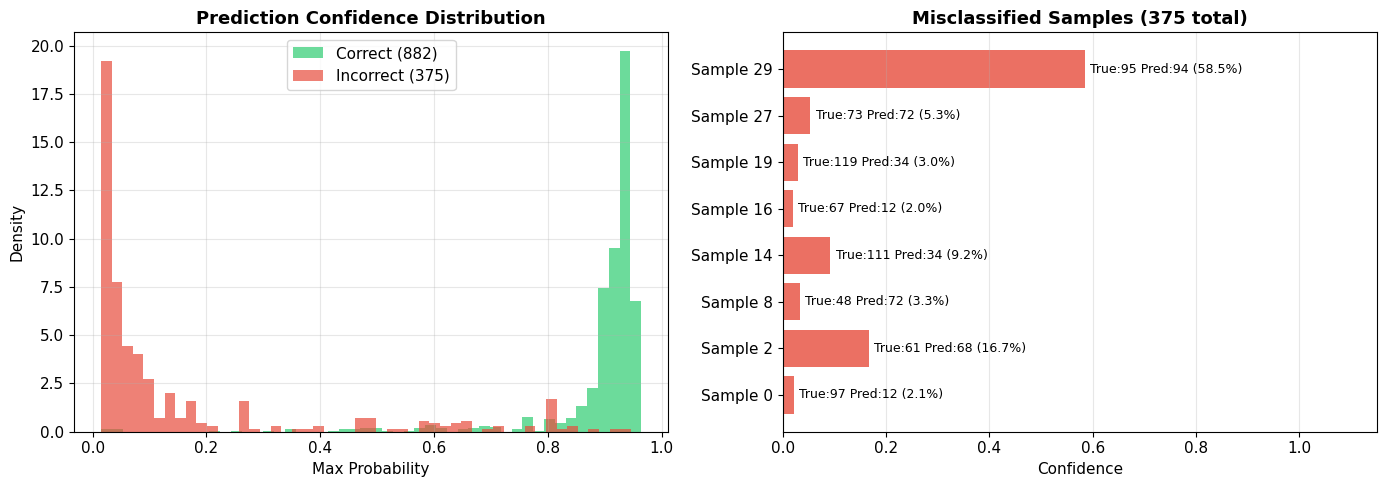


🔍 Confidence Stats
   Mean confidence (correct):   0.8951
   Mean confidence (incorrect): 0.1525
   High confidence (>95%):      65 / 1,257


In [12]:
# Confidence distribution for correct vs incorrect predictions
max_probs = all_probs.max(axis=1)
correct_mask = (all_preds == all_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence histogram
axes[0].hist(max_probs[correct_mask], bins=50, alpha=0.7, label=f'Correct ({correct_mask.sum():,})', color='#2ecc71', density=True)
axes[0].hist(max_probs[~correct_mask], bins=50, alpha=0.7, label=f'Incorrect ({(~correct_mask).sum():,})', color='#e74c3c', density=True)
axes[0].set_title('Prediction Confidence Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Max Probability')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Show misclassified samples
wrong_idx = np.where(~correct_mask)[0]
if len(wrong_idx) > 0:
    n_show = min(8, len(wrong_idx))
    for i in range(n_show):
        idx = wrong_idx[i]
        axes[1].barh(i, max_probs[idx], color='#e74c3c', alpha=0.8)
        axes[1].text(max_probs[idx] + 0.01, i,
                    f'True:{all_labels[idx]} Pred:{all_preds[idx]} ({max_probs[idx]:.1%})',
                    va='center', fontsize=9)
    axes[1].set_yticks(range(n_show))
    axes[1].set_yticklabels([f'Sample {wrong_idx[i]}' for i in range(n_show)])
    axes[1].set_title(f'Misclassified Samples ({len(wrong_idx)} total)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Confidence')
    axes[1].set_xlim(0, 1.15)
    axes[1].grid(True, alpha=0.3, axis='x')
else:
    axes[1].text(0.5, 0.5, 'No misclassified samples! 🎉',
                ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title('Misclassified Samples', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(str(Path(config['paths']['outputs_dir']) / 'confidence_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🔍 Confidence Stats")
print(f"   Mean confidence (correct):   {max_probs[correct_mask].mean():.4f}")
if (~correct_mask).sum() > 0:
    print(f"   Mean confidence (incorrect): {max_probs[~correct_mask].mean():.4f}")
print(f"   High confidence (>95%):      {(max_probs > 0.95).sum():,} / {len(max_probs):,}")

---
## 10. 📋 Final Summary

In [13]:
print("=" * 60)
print("  TRAINING COMPLETE -- FINAL RESULTS")
print("=" * 60)
print(f"")
print(f"  Model:           ConvNeXt-Tiny + Transformer")
print(f"  Dataset:         Sri Lankan Traffic Signs (122 classes)")
print(f"  Epochs trained:  {len(history['train_loss'])}")
print(f"")
print(f"  VALIDATION")
print(f"  -----------")
print(f"  Best Accuracy:   {max(history['val_acc']):.4f} ({max(history['val_acc'])*100:.2f}%)")
print(f"  Best F1 (Macro): {best_f1:.4f}")
print(f"")
print(f"  TEST SET")
print(f"  -----------")
print(f"  Accuracy:        {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  F1 (Macro):      {test_f1:.4f}")
print(f"  Precision:       {test_precision:.4f}")
print(f"  Recall:          {test_recall:.4f}")
print(f"")
print(f"  SAVED ARTIFACTS")
print(f"  -----------")
print(f"  Best model:      {config['paths']['models_dir']}/best_model.pth")
print(f"  Weights only:    {config['paths']['models_dir']}/best_model_weights.pth")
print(f"  Training curves: {config['paths']['outputs_dir']}/training_curves.png")
print(f"  Test metrics:    {config['paths']['outputs_dir']}/test_metrics.json")
print(f"  Confusion:       {config['paths']['outputs_dir']}/confusion_analysis.png")
print(f"  Confidence:      {config['paths']['outputs_dir']}/confidence_analysis.png")
print("=" * 60)

  TRAINING COMPLETE -- FINAL RESULTS

  Model:           ConvNeXt-Tiny + Transformer
  Dataset:         Sri Lankan Traffic Signs (122 classes)
  Epochs trained:  32

  VALIDATION
  -----------
  Best Accuracy:   0.6938 (69.38%)
  Best F1 (Macro): 0.7293

  TEST SET
  -----------
  Accuracy:        0.7017 (70.17%)
  F1 (Macro):      0.7161
  Precision:       0.8143
  Recall:          0.6763

  SAVED ARTIFACTS
  -----------
  Best model:      D:\APIIT\FYP\Traffic-Sign-Recognition\models_sri_lanka/best_model.pth
  Weights only:    D:\APIIT\FYP\Traffic-Sign-Recognition\models_sri_lanka/best_model_weights.pth
  Training curves: D:\APIIT\FYP\Traffic-Sign-Recognition\outputs_sri_lanka/training_curves.png
  Test metrics:    D:\APIIT\FYP\Traffic-Sign-Recognition\outputs_sri_lanka/test_metrics.json
  Confusion:       D:\APIIT\FYP\Traffic-Sign-Recognition\outputs_sri_lanka/confusion_analysis.png
  Confidence:      D:\APIIT\FYP\Traffic-Sign-Recognition\outputs_sri_lanka/confidence_analysis.png
